### smol project that codes a custom multi layer perceptron from scratch using numpy and pandas on the mnist dataset.

simple neural net with one hidden layer. ran into a couple of dimensionality errors during the initial run but other than that its pretty straightforward

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df = pd.read_csv('train.csv')
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
m, n = df.shape
df = df.sample(frac=1).reset_index(drop=True)
print(m, "  ", n)

42000    785


In [4]:
X_all = df.iloc[:, 1:].astype(np.float32).values.T
y_all = df.iloc[:, 0].astype(np.float32).values


print(X_all.shape)

X_all /= 255.0

test_size = 1000

X_test = X_all[:, :test_size]
y_test = y_all[:test_size]
X_train = X_all[:, test_size:]
y_train = y_all[test_size:]

# print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(784, 42000)


In [5]:
def one_hot_encoder(Y, num_classes):
    m = Y.size
    onehotY = np.zeros((num_classes, m))
    onehotY[Y.astype(int), np.arange(m)] = 1
    return onehotY

def ReLU(Z):
    return np.maximum(0, Z)

def softmax(Z):
    Z = Z - np.max(Z, axis=0, keepdims=True)
    expZ = np.exp(Z)
    return expZ / np.sum(expZ, axis=0, keepdims=True)

def d_ReLU(Z):
    return (Z>0).astype(float)

def init_params(nx, nh, ny):
    W1 = np.random.randn(nh, nx) * np.sqrt(2/nx)
    b1 = np.zeros((nh, 1))
    W2 = np.random.randn(ny, nh) * np.sqrt(2/nh)
    b2 = np.zeros((ny, 1))

    return W1, b1, W2, b2

def compute_loss(A2, Y):
    m = Y.size
    onehotY = one_hot_encoder(Y, A2.shape[0])
    log_probability = np.log(A2 + 1e-8) * onehotY
    loss = -np.sum(log_probability) / m

    return loss


def forward_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)

    return Z1 ,A1, Z2, A2

def backward_prop(Z1, A1, Z2, A2, W2, X, Y):
    m = Y.size
    onehotY = one_hot_encoder(Y, A2.shape[0])

    dZ2 = A2 - onehotY
    dW2 = 1.0/m * dZ2.dot(A1.T)
    db2 = 1.0/m * np.sum(dZ2, axis=1, keepdims=True)

    dZ1 = W2.T.dot(dZ2) * d_ReLU(Z1)
    dW1 = 1.0/m * dZ1.dot(X.T)
    db1 = 1.0/m * np.sum(dZ1, axis=1, keepdims=True)

    return dW1, db1, dW2, db2

def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 -= alpha * dW1
    b1 -= alpha * db1
    W2 -= alpha * dW2
    b2 -= alpha * db2

    return W1, b1, W2, b2

def get_predictions(A2):
    return np.argmax(A2, axis=0)

def get_accuracy(predictions, Y):
    return np.sum(predictions == Y) / Y.size


In [6]:
def train(X, Y, nh=128, epochs=10, batch_size=128, alpha=0.01):
    nx = X.shape[0]
    ny = 10

    W1, b1, W2, b2 = init_params(nx, nh, ny)

    for epoch in range(epochs):
        for i in range(0, Y.size, batch_size):
            X_batch = X[:, i:i+batch_size]
            Y_batch = Y[i : i+batch_size]

            Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X_batch)

            dW1, db1, dW2, db2 = backward_prop(Z1, A1, Z2, A2, W2, X_batch, Y_batch)
            W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)

        if((epoch+1)%3 == 0):
            loss = compute_loss(A2, Y_batch)
            predictions = get_predictions(A2)
            accuracy = get_accuracy(predictions, Y_batch)
            print(f'epoch: {epoch+1}/{epochs}, loss = {loss:.2f}, accuracy = {accuracy:.2f}')

    return W1, b1, W2, b2


In [7]:
W1, b1, W2, b2 = train(X_train, y_train, nh=128, epochs=10, batch_size=64, alpha=0.01)

epoch: 3/10, loss = 0.42, accuracy = 0.90
epoch: 6/10, loss = 0.37, accuracy = 0.90
epoch: 9/10, loss = 0.34, accuracy = 0.90


In [8]:
Z1_test, A1_test, Z2_test, A2_test = forward_prop(W1, b1, W2, b2, X_test)
test_predictions = get_predictions(A2_test)
test_accuracy = get_accuracy(test_predictions, y_test)

print(f'Test accuracy =  {test_accuracy:.4f}')



Test accuracy =  0.9380


In [9]:
def plot_image(index):
    image = X_train[:, index, None]
    label = y_train[index]
    _ , _ , _ , A2_test = forward_prop(W1, b1, W2, b2, image)
    test_predictions = get_predictions(A2_test)
    print("Prediction: ", test_predictions)
    print("Label: ", label)
    image = image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(image, interpolation='nearest')
    plt.show()

Prediction:  [6]
Label:  6.0


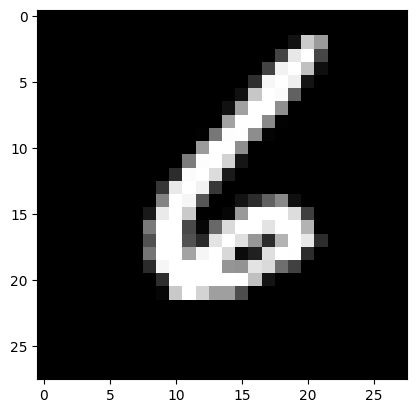

In [12]:
plot_image(323)